# 09 – ASRS Filter Study (Tom Hougaard)

**Instrument** : DAX 40 Futures (DE40), 5-min data  
**Baseline** : ASRS 4th bar (PF 1.08, Sharpe 0.40, total 6,029 pts)

## Three filters tested
| # | Filter | Rule |
|---|--------|------|
| F1 | No Friday | Skip any trade day where dayofweek == Friday |
| F2 | Range filter | Only trade when signal bar range is between 10 and 55 pts |
| F3 | Breakeven stop | Once trade is +15 pts in profit, move stop to entry (no loss possible) |

## Variants run
1. `baseline`    — no filters (reproduces nb08 result)
2. `f1_no_fri`   — Friday skip only
3. `f2_range`    — range filter only
4. `f3_be`       — breakeven stop only
5. `all_filters` — F1 + F2 + F3 combined

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import warnings
warnings.filterwarnings('ignore')

ROOT = Path.cwd()
while not (ROOT / 'pyproject.toml').exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT))

print(f'ROOT = {ROOT}')

ROOT = c:\Users\ali\Desktop\Projet-INFO-2AS2


## 1. Load & Prepare Data

In [2]:
DATA_PATH = ROOT / 'data' / 'dax-5m_bk.csv'

raw = pd.read_csv(
    DATA_PATH,
    sep=';',
    header=None,
    names=['date', 'time', 'open', 'high', 'low', 'close', 'volume'],
)

raw['datetime'] = pd.to_datetime(raw['date'] + ' ' + raw['time'], format='%d/%m/%Y %H:%M')
raw = raw.drop(columns=['date', 'time']).set_index('datetime').sort_index()

START_DATE = '2006-01-01'
raw = raw[raw.index >= START_DATE]

print(f'Loaded {len(raw):,} rows from {raw.index[0].date()} to {raw.index[-1].date()}')

Loaded 998,622 rows from 2006-01-02 to 2026-04-06


## 2. Parameters

In [3]:
# ── Base strategy ─────────────────────────────────────────────────────────────
ENTRY_BUFFER     = 2        # pts beyond signal bar high/low
EOD_EXIT_TIME    = '17:30'  # CET
SIGNAL_BAR_4     = '09:15'  # 4th 5-min candle after open

# ── Filter parameters ─────────────────────────────────────────────────────────
RANGE_MIN        = 10       # F2: minimum signal bar range (pts)
RANGE_MAX        = 55       # F2: maximum signal bar range (pts)
BREAKEVEN_TRIGGER = 15      # F3: pts of open profit before stop moves to entry

print('Parameters set.')
print(f'  Entry buffer       : {ENTRY_BUFFER} pts')
print(f'  EOD exit           : {EOD_EXIT_TIME} CET')
print(f'  Signal bar         : {SIGNAL_BAR_4} CET')
print(f'  Range filter       : {RANGE_MIN}–{RANGE_MAX} pts  (F2)')
print(f'  Breakeven trigger  : +{BREAKEVEN_TRIGGER} pts     (F3)')

Parameters set.
  Entry buffer       : 2 pts
  EOD exit           : 17:30 CET
  Signal bar         : 09:15 CET
  Range filter       : 10–55 pts  (F2)
  Breakeven trigger  : +15 pts     (F3)


## 3. Signal Bar Extraction

In [4]:
bars_4th = raw[raw.index.strftime('%H:%M') == SIGNAL_BAR_4].copy()
bars_4th['bar_range'] = bars_4th['high'] - bars_4th['low']
bars_4th = bars_4th[(bars_4th['bar_range'] > 0.1) & (bars_4th['bar_range'] < 500)]
bars_4th['trade_date'] = bars_4th.index.date
bars_4th_by_date = bars_4th.set_index('trade_date')

print(f'4th bar days found : {len(bars_4th):,}')
print(f'Avg bar range      : {bars_4th["bar_range"].mean():.1f} pts')
print(f'Days in range {RANGE_MIN}–{RANGE_MAX} pts: '
      f'{((bars_4th["bar_range"] >= RANGE_MIN) & (bars_4th["bar_range"] <= RANGE_MAX)).sum():,} '
      f'({((bars_4th["bar_range"] >= RANGE_MIN) & (bars_4th["bar_range"] <= RANGE_MAX)).mean()*100:.1f}%)')

4th bar days found : 5,136
Avg bar range      : 17.1 pts
Days in range 10–55 pts: 3,654 (71.1%)


## 4. Backtest Engine (with filter flags)

In [5]:
def simulate_day_filtered(
    day_bars: pd.DataFrame,
    sig_high: float,
    sig_low: float,
    use_breakeven: bool = False,
):
    """
    Simulate one ASRS day with optional breakeven stop (F3).

    Stop starts at the opposite entry price.
    If use_breakeven=True, once trade profits >= BREAKEVEN_TRIGGER pts
    the stop is moved to the entry price — can no longer lose on this trade.
    """
    if day_bars.empty:
        return None

    entry_long  = sig_high + ENTRY_BUFFER
    entry_short = sig_low  - ENTRY_BUFFER
    stop_long   = entry_short
    stop_short  = entry_long

    direction   = None
    entry_price = None
    entry_time  = None
    stop        = None

    # ── Phase 1: find first entry ──────────────────────────────────────────────
    for ts, bar in day_bars.iterrows():
        if direction is not None:
            break
        bar_h, bar_l = bar['high'], bar['low']
        long_hit  = bar_h >= entry_long
        short_hit = bar_l <= entry_short

        if long_hit and short_hit:
            if bar['open'] >= entry_long:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            elif bar['open'] <= entry_short:
                direction, entry_price, stop = 'short', entry_short, stop_short
            else:
                direction, entry_price, stop = 'long',  entry_long,  stop_long
            entry_time = ts
        elif long_hit:
            direction, entry_price, stop, entry_time = 'long',  entry_long,  stop_long,  ts
        elif short_hit:
            direction, entry_price, stop, entry_time = 'short', entry_short, stop_short, ts

    if direction is None:
        return None

    initial_risk      = abs(entry_price - stop)
    max_adverse       = 0.0
    max_favorable     = 0.0
    breakeven_triggered = False

    exit_price  = None
    exit_time   = None
    exit_reason = 'eod'

    in_trade_bars = day_bars[day_bars.index >= entry_time]

    # ── Phase 2: manage trade ──────────────────────────────────────────────────
    for ts, bar in in_trade_bars.iterrows():
        bar_h, bar_l = bar['high'], bar['low']

        if direction == 'long':
            max_adverse   = max(max_adverse,   entry_price - bar_l)
            max_favorable = max(max_favorable, bar_h - entry_price)

            # F3: move stop to breakeven once +BREAKEVEN_TRIGGER pts
            if use_breakeven and not breakeven_triggered:
                if bar_h >= entry_price + BREAKEVEN_TRIGGER:
                    stop = entry_price          # can't lose now
                    breakeven_triggered = True

            if bar_l <= stop:
                reason = 'breakeven' if (breakeven_triggered and stop == entry_price) else 'stop'
                exit_price, exit_time, exit_reason = stop, ts, reason
                break

        else:  # short
            max_adverse   = max(max_adverse,   bar_h - entry_price)
            max_favorable = max(max_favorable, entry_price - bar_l)

            # F3: move stop to breakeven
            if use_breakeven and not breakeven_triggered:
                if bar_l <= entry_price - BREAKEVEN_TRIGGER:
                    stop = entry_price
                    breakeven_triggered = True

            if bar_h >= stop:
                reason = 'breakeven' if (breakeven_triggered and stop == entry_price) else 'stop'
                exit_price, exit_time, exit_reason = stop, ts, reason
                break

    if exit_price is None:
        last = in_trade_bars.iloc[-1]
        exit_price  = last['close']
        exit_time   = in_trade_bars.index[-1]
        exit_reason = 'eod'

    pnl = (exit_price - entry_price) if direction == 'long' else (entry_price - exit_price)

    return {
        'direction'          : direction,
        'entry_price'        : round(entry_price,  2),
        'entry_time'         : entry_time,
        'exit_price'         : round(exit_price,   2),
        'exit_time'          : exit_time,
        'exit_reason'        : exit_reason,
        'stop_initial'       : round(abs(entry_price - (stop_long if direction=='long' else stop_short)), 2),
        'pnl'                : round(pnl,           2),
        'max_adverse'        : round(max_adverse,   2),
        'max_favorable'      : round(max_favorable, 2),
        'sig_range'          : round(sig_high - sig_low, 2),
        'breakeven_triggered': breakeven_triggered,
    }

print('simulate_day_filtered() defined.')

simulate_day_filtered() defined.


In [6]:
def run_backtest_filtered(
    no_friday:     bool = False,
    range_filter:  bool = False,
    use_breakeven: bool = False,
) -> pd.DataFrame:
    """
    Run ASRS backtest with optional filters.

    no_friday    : F1 — skip days where dayofweek == 4 (Friday)
    range_filter : F2 — skip days where signal bar range < RANGE_MIN or > RANGE_MAX
    use_breakeven: F3 — move stop to entry after BREAKEVEN_TRIGGER pts profit
    """
    trades = []
    trading_dates = bars_4th_by_date.index.unique()

    for trade_date in trading_dates:
        ts_date = pd.Timestamp(trade_date)

        # F1: skip Fridays
        if no_friday and ts_date.dayofweek == 4:
            continue

        row4 = bars_4th_by_date.loc[trade_date]
        if isinstance(row4, pd.DataFrame):
            row4 = row4.iloc[0]

        sig_high  = row4['high']
        sig_low   = row4['low']
        sig_range = sig_high - sig_low

        # F2: range filter
        if range_filter and not (RANGE_MIN <= sig_range <= RANGE_MAX):
            continue

        day_start = pd.Timestamp(f"{trade_date} 09:20")
        day_end   = pd.Timestamp(f"{trade_date} {EOD_EXIT_TIME}")
        day_bars  = raw.loc[day_start:day_end]

        if len(day_bars) < 2:
            continue

        result = simulate_day_filtered(
            day_bars,
            sig_high,
            sig_low,
            use_breakeven=use_breakeven,
        )

        if result is not None:
            result['trade_date'] = ts_date
            trades.append(result)

    df = pd.DataFrame(trades).set_index('trade_date').sort_index()
    return df


print('run_backtest_filtered() defined. Running all 5 variants...')

results = {
    'baseline'   : run_backtest_filtered(no_friday=False, range_filter=False, use_breakeven=False),
    'f1_no_fri'  : run_backtest_filtered(no_friday=True,  range_filter=False, use_breakeven=False),
    'f2_range'   : run_backtest_filtered(no_friday=False, range_filter=True,  use_breakeven=False),
    'f3_be'      : run_backtest_filtered(no_friday=False, range_filter=False, use_breakeven=True),
    'all_filters': run_backtest_filtered(no_friday=True,  range_filter=True,  use_breakeven=True),
}

for k, df in results.items():
    print(f'  {k:15s} : {len(df):,} trades')

run_backtest_filtered() defined. Running all 5 variants...
  baseline        : 5,135 trades
  f1_no_fri       : 4,121 trades
  f2_range        : 3,654 trades
  f3_be           : 5,135 trades
  all_filters     : 2,904 trades


## 5. Performance Metrics

In [7]:
def compute_metrics(df: pd.DataFrame, label: str = '') -> dict:
    if df.empty:
        return {'label': label}

    n_trades  = len(df)
    winners   = df[df['pnl'] > 0]
    losers    = df[df['pnl'] < 0]
    n_win     = len(winners)
    n_loss    = len(losers)
    win_rate  = n_win / n_trades * 100

    avg_win   = winners['pnl'].mean() if n_win  else 0
    avg_loss  = losers ['pnl'].mean() if n_loss else 0

    gross_profit  = winners['pnl'].sum()    if n_win  else 0
    gross_loss    = abs(losers['pnl'].sum()) if n_loss else 1e-9
    profit_factor = gross_profit / gross_loss

    total_pnl = df['pnl'].sum()

    sharpe = (df['pnl'].mean() / df['pnl'].std() * np.sqrt(252)
              if df['pnl'].std() > 0 else 0)

    cum      = df['pnl'].cumsum()
    drawdown = cum - cum.cummax()
    max_dd   = drawdown.min()

    longs  = df[df['direction'] == 'long']
    shorts = df[df['direction'] == 'short']

    win_loss_ratio = abs(avg_win / avg_loss) if avg_loss != 0 else np.inf

    n_stop = (df['exit_reason'] == 'stop').sum()
    n_be   = (df['exit_reason'] == 'breakeven').sum()
    n_eod  = (df['exit_reason'] == 'eod').sum()

    return {
        'label'          : label,
        'n_trades'       : n_trades,
        'win_rate_%'     : round(win_rate,        1),
        'avg_win_pts'    : round(avg_win,          1),
        'avg_loss_pts'   : round(avg_loss,         1),
        'win_loss_ratio' : round(win_loss_ratio,   2),
        'profit_factor'  : round(profit_factor,    2),
        'total_pnl_pts'  : round(total_pnl,        0),
        'avg_trade_pts'  : round(df['pnl'].mean(), 2),
        'sharpe'         : round(sharpe,           2),
        'max_dd_pts'     : round(max_dd,           0),
        'wr_long_%'      : round((longs ['pnl'] > 0).mean()*100, 1) if len(longs)  else 0,
        'wr_short_%'     : round((shorts['pnl'] > 0).mean()*100, 1) if len(shorts) else 0,
        'n_longs'        : len(longs),
        'n_shorts'       : len(shorts),
        'n_stop'         : int(n_stop),
        'n_breakeven'    : int(n_be),
        'n_eod'          : int(n_eod),
    }


rows = [compute_metrics(df, label=k) for k, df in results.items()]
summary = pd.DataFrame(rows).set_index('label')

cols_display = [
    'n_trades', 'win_rate_%', 'avg_win_pts', 'avg_loss_pts',
    'win_loss_ratio', 'profit_factor', 'total_pnl_pts',
    'avg_trade_pts', 'sharpe', 'max_dd_pts',
]

print('=== ASRS Filter Comparison ===')
print(summary[cols_display].to_string())

=== ASRS Filter Comparison ===
             n_trades  win_rate_%  avg_win_pts  avg_loss_pts  win_loss_ratio  profit_factor  total_pnl_pts  avg_trade_pts  sharpe  max_dd_pts
label                                                                                                                                        
baseline         5135        28.2         55.0         -20.0            2.75           1.08         6029.0           1.17    0.40     -2971.0
f1_no_fri        4121        28.2         56.3         -19.7            2.85           1.12         6914.0           1.68    0.56     -2045.0
f2_range         3654        29.6         61.3         -22.6            2.71           1.14         8080.0           2.21    0.68     -2314.0
f3_be            5135        11.3         46.3         -18.3            2.52           0.63       -15879.0          -3.09   -1.94    -16085.0
all_filters      2904        10.0         56.5         -21.9            2.58           0.64        -9404.0          -

In [8]:
# Improvement vs baseline
base = summary.loc['baseline']
print('=== Improvement vs Baseline ===')
print(f'{"Variant":<15}  {"Trades":>7}  {"PnL Δ":>9}  {"PF Δ":>7}  {"Sharpe Δ":>9}  {"MaxDD Δ":>9}')
print('-' * 65)
for label, row in summary.iterrows():
    if label == 'baseline':
        print(f'{label:<15}  {row["n_trades"]:>7,}  '
              f'{row["total_pnl_pts"]:>+9,.0f}  '
              f'{row["profit_factor"]:>7.2f}  '
              f'{row["sharpe"]:>9.2f}  '
              f'{row["max_dd_pts"]:>+9,.0f}  ← baseline')
    else:
        pnl_delta    = row['total_pnl_pts'] - base['total_pnl_pts']
        pf_delta     = row['profit_factor'] - base['profit_factor']
        sharpe_delta = row['sharpe']        - base['sharpe']
        dd_delta     = row['max_dd_pts']    - base['max_dd_pts']
        print(f'{label:<15}  {row["n_trades"]:>7,}  '
              f'{pnl_delta:>+9,.0f}  '
              f'{pf_delta:>+7.2f}  '
              f'{sharpe_delta:>+9.2f}  '
              f'{dd_delta:>+9,.0f}')

=== Improvement vs Baseline ===
Variant           Trades      PnL Δ     PF Δ   Sharpe Δ    MaxDD Δ
-----------------------------------------------------------------
baseline         5,135.0     +6,029     1.08       0.40     -2,971  ← baseline
f1_no_fri        4,121.0       +885    +0.04      +0.16       +926
f2_range         3,654.0     +2,051    +0.06      +0.28       +657
f3_be            5,135.0    -21,908    -0.45      -2.34    -13,114
all_filters      2,904.0    -15,433    -0.44      -2.24     -6,650


## 6. Equity Curves — All Variants

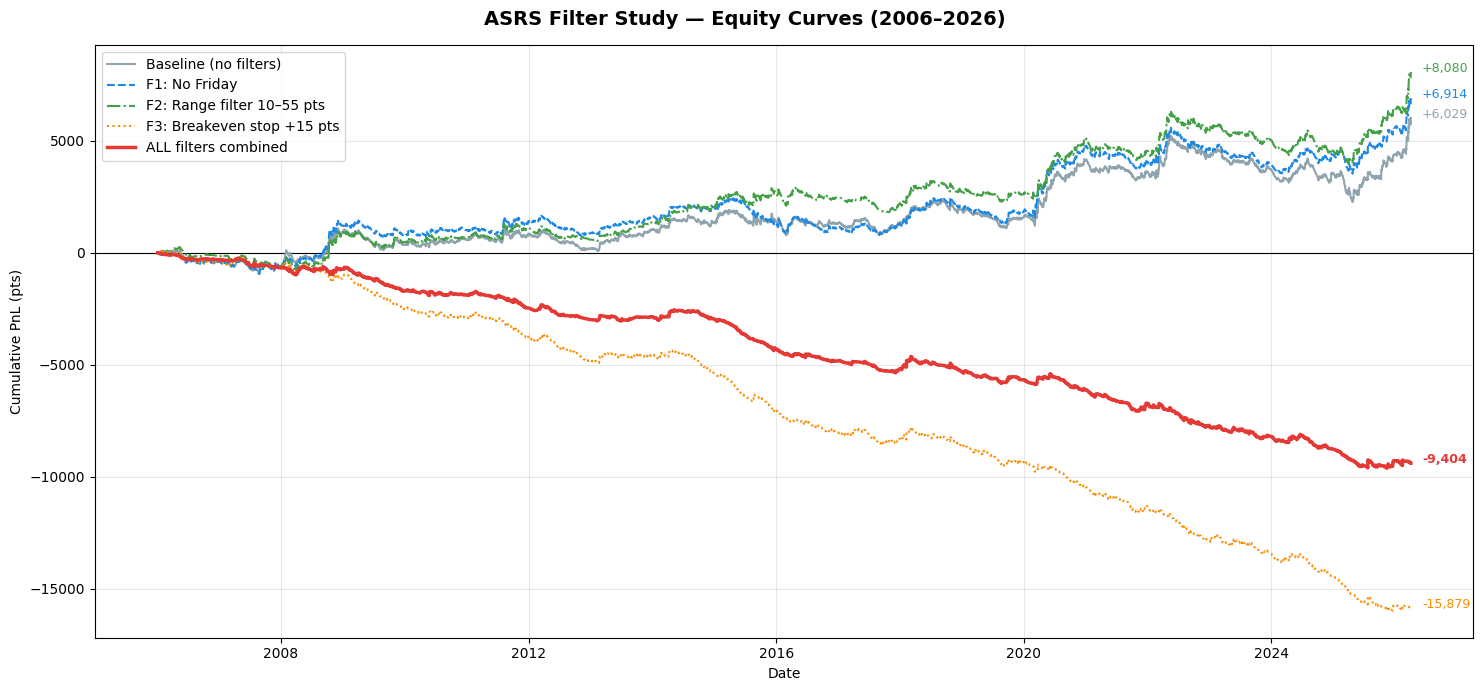

Saved: asrs_filters_equity.png


In [9]:
colors = {
    'baseline'   : ('#90A4AE', '-',  'Baseline (no filters)'),
    'f1_no_fri'  : ('#1E88E5', '--', 'F1: No Friday'),
    'f2_range'   : ('#43A047', '-.', 'F2: Range filter 10–55 pts'),
    'f3_be'      : ('#FB8C00', ':',  'F3: Breakeven stop +15 pts'),
    'all_filters': ('#E53935', '-',  'ALL filters combined'),
}

fig, ax = plt.subplots(figsize=(15, 7))
fig.suptitle('ASRS Filter Study — Equity Curves (2006–2026)', fontsize=14, fontweight='bold')

for key, (color, ls, label) in colors.items():
    df_v = results[key]
    cum  = df_v['pnl'].cumsum()
    lw   = 2.5 if key == 'all_filters' else 1.5
    ax.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label, zorder=5 if key=='all_filters' else 3)

ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Cumulative PnL (pts)')
ax.set_xlabel('Date')
ax.legend(loc='upper left', fontsize=10)
ax.grid(True, alpha=0.3)

# Annotate final values
for key, (color, ls, label) in colors.items():
    final_pnl = results[key]['pnl'].sum()
    ax.annotate(f'{final_pnl:+,.0f}',
                xy=(results[key].index[-1], final_pnl),
                xytext=(8, 0), textcoords='offset points',
                color=color, fontsize=9, fontweight='bold' if key=='all_filters' else 'normal')

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'asrs_filters_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_filters_equity.png')

## 7. Annual Performance — Baseline vs All Filters

In [10]:
def annual_pnl(df):
    return df.groupby(df.index.year)['pnl'].sum().round(1)

ann_base    = annual_pnl(results['baseline'])
ann_all     = annual_pnl(results['all_filters'])
ann_compare = pd.DataFrame({'baseline': ann_base, 'all_filters': ann_all})
ann_compare['improvement'] = (ann_compare['all_filters'] - ann_compare['baseline']).round(1)

print('=== Annual PnL: Baseline vs All Filters ===')
print(f'{"Year":<6}  {"Baseline":>10}  {"All Filters":>12}  {"Improvement":>12}')
print('-' * 45)
for yr, row in ann_compare.iterrows():
    marker = ' ✓' if row['improvement'] > 0 else ' ✗'
    print(f'{yr:<6}  {row["baseline"]:>+10.0f}  {row["all_filters"]:>+12.0f}  {row["improvement"]:>+12.0f}{marker}')

better_years = (ann_compare['improvement'] > 0).sum()
print(f'\nAll-filters beat baseline in {better_years}/{len(ann_compare)} years')

=== Annual PnL: Baseline vs All Filters ===
Year      Baseline   All Filters   Improvement
---------------------------------------------
2006          -311          -296           +15 ✓
2007          -355          -371           -16 ✗
2008         +1537           -66         -1604 ✗
2009          -518          -987          -469 ✗
2010          +250          -161          -411 ✗
2011          +243          -579          -822 ✗
2012          -672          -520          +152 ✓
2013          +860          +124          -736 ✗
2014          +303           -88          -391 ✗
2015           +74         -1345         -1419 ✗
2016          -106          -552          -446 ✗
2017           +80          -340          -420 ✗
2018          +523          -119          -642 ✗
2019          -322          -371           -49 ✗
2020         +2515          -453         -2968 ✗
2021          -478          -594          -117 ✗
2022          +705         -1009         -1714 ✗
2023          -603          -4

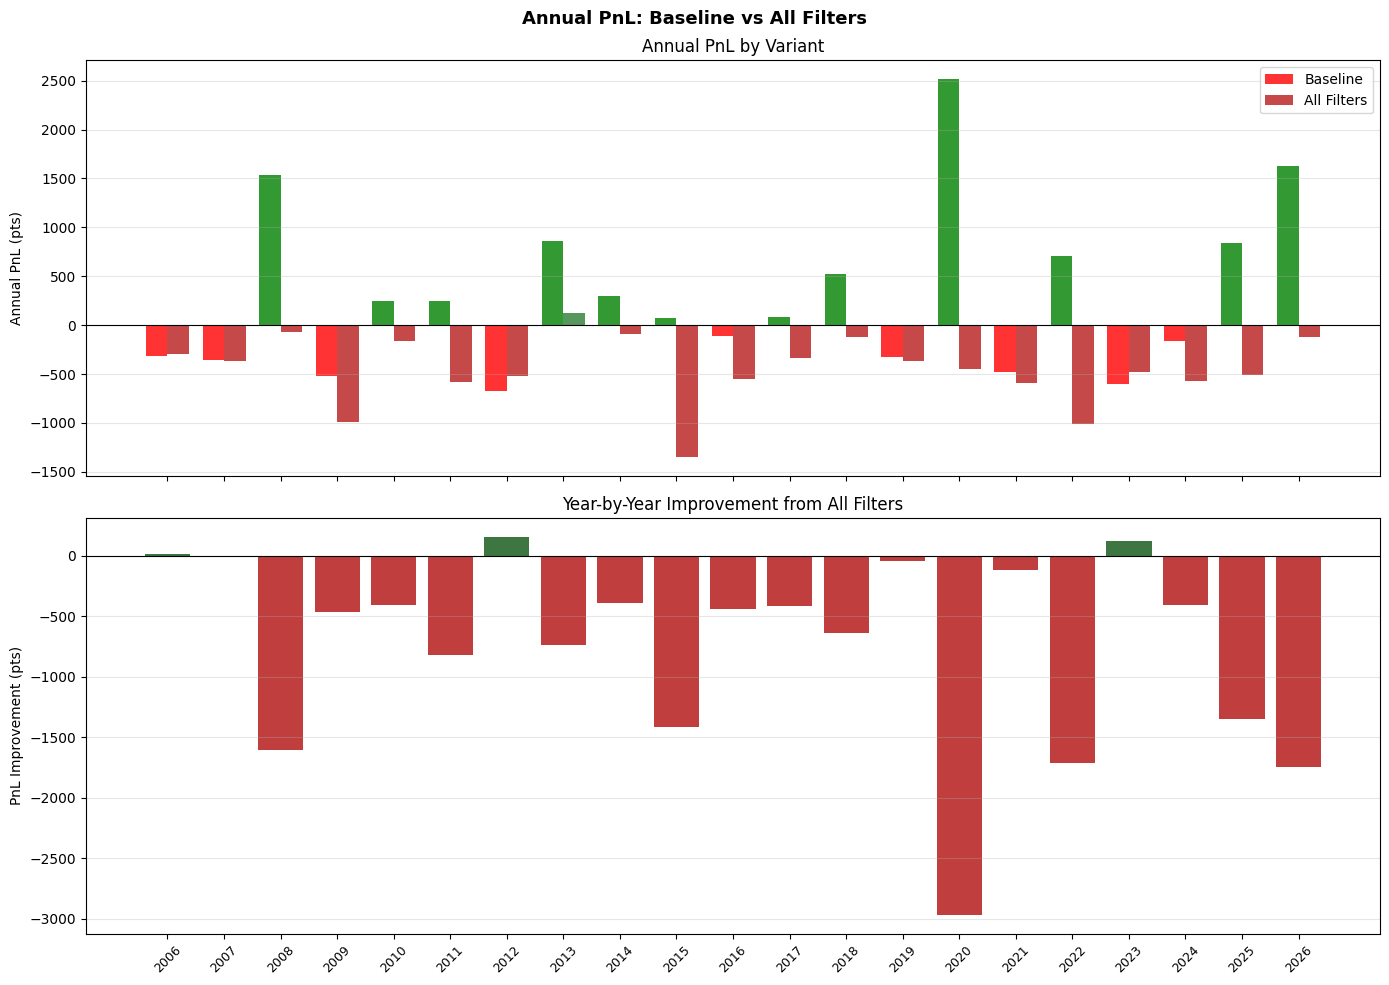

Saved: asrs_filters_annual.png


In [11]:
# Annual bar chart comparison
fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)
fig.suptitle('Annual PnL: Baseline vs All Filters', fontsize=13, fontweight='bold')

years = ann_compare.index.astype(str)
x     = np.arange(len(years))
w     = 0.38

ax = axes[0]
cols_base = ['green' if v > 0 else 'red' for v in ann_compare['baseline']]
cols_all  = ['#2E7D32' if v > 0 else '#B71C1C' for v in ann_compare['all_filters']]
ax.bar(x - w/2, ann_compare['baseline'],    w, color=cols_base, alpha=0.8, label='Baseline')
ax.bar(x + w/2, ann_compare['all_filters'], w, color=cols_all,  alpha=0.8, label='All Filters')
ax.axhline(0, color='black', lw=0.8)
ax.set_ylabel('Annual PnL (pts)')
ax.set_title('Annual PnL by Variant')
ax.legend()
ax.grid(True, axis='y', alpha=0.3)

ax2 = axes[1]
imp_colors = ['#1B5E20' if v > 0 else '#B71C1C' for v in ann_compare['improvement']]
ax2.bar(x, ann_compare['improvement'], color=imp_colors, alpha=0.85)
ax2.axhline(0, color='black', lw=0.8)
ax2.set_ylabel('PnL Improvement (pts)')
ax2.set_title('Year-by-Year Improvement from All Filters')
ax2.set_xticks(x)
ax2.set_xticklabels(years, rotation=45, fontsize=9)
ax2.grid(True, axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'asrs_filters_annual.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_filters_annual.png')

## 8. Breakeven Analysis (F3 deep-dive)

In [12]:
df_be = results['f3_be']

n_be_triggered = df_be['breakeven_triggered'].sum()
n_be_exit      = (df_be['exit_reason'] == 'breakeven').sum()

# Trades where breakeven was triggered — compare PnL when stopped at BE vs continued to EOD/profit
be_trades       = df_be[df_be['breakeven_triggered']]
non_be_trades   = df_be[~df_be['breakeven_triggered']]

print(f'F3 Breakeven analysis:')
print(f'  Total trades              : {len(df_be):,}')
print(f'  Breakeven triggered       : {n_be_triggered:,} ({n_be_triggered/len(df_be)*100:.1f}%)')
print(f'  Exited AT breakeven (0 pts): {n_be_exit:,} ({n_be_exit/len(df_be)*100:.1f}%)')
print()
print(f'  Trades where BE triggered:')
print(f'    Count         : {len(be_trades):,}')
print(f'    Avg PnL       : {be_trades["pnl"].mean():.1f} pts')
print(f'    Win rate      : {(be_trades["pnl"] > 0).mean()*100:.1f}%')
print(f'    Total PnL     : {be_trades["pnl"].sum():.0f} pts')
print()
print(f'  Trades where BE NOT triggered:')
print(f'    Count         : {len(non_be_trades):,}')
print(f'    Avg PnL       : {non_be_trades["pnl"].mean():.1f} pts')
print(f'    Win rate      : {(non_be_trades["pnl"] > 0).mean()*100:.1f}%')
print(f'    Total PnL     : {non_be_trades["pnl"].sum():.0f} pts')

# What did baseline do on those same days?
df_base = results['baseline']
be_dates = be_trades.index
base_same_days = df_base[df_base.index.isin(be_dates)]
print()
print(f'  Those {len(be_dates):,} days in BASELINE: avg PnL = {base_same_days["pnl"].mean():.1f} pts, '
      f'total = {base_same_days["pnl"].sum():.0f} pts')
print(f'  Those {len(be_dates):,} days in F3_BE:    avg PnL = {be_trades["pnl"].mean():.1f} pts, '
      f'total = {be_trades["pnl"].sum():.0f} pts')
print(f'  Net effect of BE on those days: {be_trades["pnl"].sum() - base_same_days["pnl"].sum():+.0f} pts')

F3 Breakeven analysis:
  Total trades              : 5,135
  Breakeven triggered       : 2,769 (53.9%)
  Exited AT breakeven (0 pts): 2,230 (43.4%)

  Trades where BE triggered:
    Count         : 2,769
    Avg PnL       : 9.6 pts
    Win rate      : 19.5%
    Total PnL     : 26547 pts

  Trades where BE NOT triggered:
    Count         : 2,366
    Avg PnL       : -17.9 pts
    Win rate      : 1.7%
    Total PnL     : -42426 pts

  Those 2,769 days in BASELINE: avg PnL = 17.5 pts, total = 48455 pts
  Those 2,769 days in F3_BE:    avg PnL = 9.6 pts, total = 26547 pts
  Net effect of BE on those days: -21908 pts


## 9. All-Filters Deep Dive

In [13]:
df_all = results['all_filters']
m_all  = compute_metrics(df_all, label='all_filters')
m_base = compute_metrics(results['baseline'], label='baseline')

print('=== All-Filters vs Baseline — Full Scorecard ===')
print(f'{"Metric":<22}  {"Baseline":>12}  {"All Filters":>12}  {"Change":>10}')
print('-' * 62)
metrics_to_show = [
    ('n_trades',       'Trades',          '', ''),
    ('win_rate_%',     'Win rate',         '%', ''),
    ('avg_win_pts',    'Avg win',          ' pts', ''),
    ('avg_loss_pts',   'Avg loss',         ' pts', ''),
    ('win_loss_ratio', 'Win/Loss ratio',   'x', ''),
    ('profit_factor',  'Profit factor',    '', ''),
    ('total_pnl_pts',  'Total PnL',        ' pts', ''),
    ('avg_trade_pts',  'Avg trade',        ' pts', ''),
    ('sharpe',         'Sharpe',           '', ''),
    ('max_dd_pts',     'Max drawdown',     ' pts', ''),
    ('n_stop',         'Stop-outs',        '', ''),
    ('n_breakeven',    'Breakeven exits',  '', ''),
    ('n_eod',          'EOD exits',        '', ''),
]
for key, label, unit, _ in metrics_to_show:
    b = m_base.get(key, 0)
    a = m_all.get(key,  0)
    if isinstance(b, float) or isinstance(a, float):
        chg = f'{a-b:+.2f}'
        b_s, a_s = f'{b:.2f}', f'{a:.2f}'
    else:
        chg = f'{a-b:+,}'
        b_s, a_s = f'{b:,}', f'{a:,}'
    print(f'{label:<22}  {b_s+unit:>12}  {a_s+unit:>12}  {chg:>10}')

=== All-Filters vs Baseline — Full Scorecard ===
Metric                      Baseline   All Filters      Change
--------------------------------------------------------------
Trades                         5,135         2,904      -2,231
Win rate                      28.20%        10.00%      -18.20
Avg win                    55.00 pts     56.50 pts       +1.50
Avg loss                  -20.00 pts    -21.90 pts       -1.90
Win/Loss ratio                 2.75x         2.58x       -0.17
Profit factor                   1.08          0.64       -0.44
Total PnL                6029.00 pts  -9404.00 pts   -15433.00
Avg trade                   1.17 pts     -3.24 pts       -4.41
Sharpe                          0.40         -1.84       -2.24
Max drawdown            -2971.00 pts  -9621.00 pts    -6650.00
Stop-outs                      3,505         1,168      -2,337
Breakeven exits                    0         1,432      +1,432
EOD exits                      1,630           304      -1,326


In [14]:
# Annual table for all_filters
df_all['year'] = df_all.index.year

ann_all_full = df_all.groupby('year').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
    avg_win   = ('pnl', lambda x: x[x > 0].mean() if (x > 0).any() else 0),
    avg_loss  = ('pnl', lambda x: x[x < 0].mean() if (x < 0).any() else 0),
).round(1)
ann_all_full['cum_pnl'] = ann_all_full['total_pnl'].cumsum().round(0)

print('=== Annual Performance — All Filters ===')
print(ann_all_full.to_string())

=== Annual Performance — All Filters ===
      trades  total_pnl  win_rate  avg_win  avg_loss  cum_pnl
year                                                         
2006      67     -296.4      14.9     28.9     -17.2   -296.0
2007      93     -370.7      17.2     37.7     -19.9   -667.0
2008     165      -66.5      10.9     80.4     -22.9   -734.0
2009     168     -987.2       8.3     34.5     -20.1  -1721.0
2010     118     -161.2      19.5     34.4     -18.7  -1882.0
2011     146     -578.9      11.6     44.5     -20.9  -2461.0
2012     110     -519.9      12.7     40.1     -19.0  -2981.0
2013      87      124.0      20.7     40.1     -19.3  -2857.0
2014     129      -88.5      17.1     45.1     -20.0  -2945.0
2015     182    -1345.4       2.7     57.6     -24.7  -4291.0
2016     148     -551.7       8.1     51.2     -21.2  -4842.0
2017     103     -339.5      13.6     41.3     -19.1  -5182.0
2018     164     -119.2       8.5     98.1     -21.6  -5301.0
2019     128     -370.9      

In [15]:
# Day-of-week for all_filters variant
df_all['dow'] = df_all.index.dayofweek
dow_map = {0: 'Mon', 1: 'Tue', 2: 'Wed', 3: 'Thu', 4: 'Fri'}

dow_perf = df_all.groupby('dow').agg(
    trades    = ('pnl', 'count'),
    total_pnl = ('pnl', 'sum'),
    win_rate  = ('pnl', lambda x: (x > 0).mean() * 100),
).round(1)
dow_perf.index = [dow_map.get(i, i) for i in dow_perf.index]

print('=== Day-of-Week Performance — All Filters ===')
print('(Fridays skipped by F1 — should not appear)')
print(dow_perf.to_string())

=== Day-of-Week Performance — All Filters ===
(Fridays skipped by F1 — should not appear)
     trades  total_pnl  win_rate
Mon     659    -2071.7      10.0
Tue     757    -2887.7      10.2
Wed     730    -1816.8      10.5
Thu     758    -2628.0       9.4


## 10. Summary Dashboard

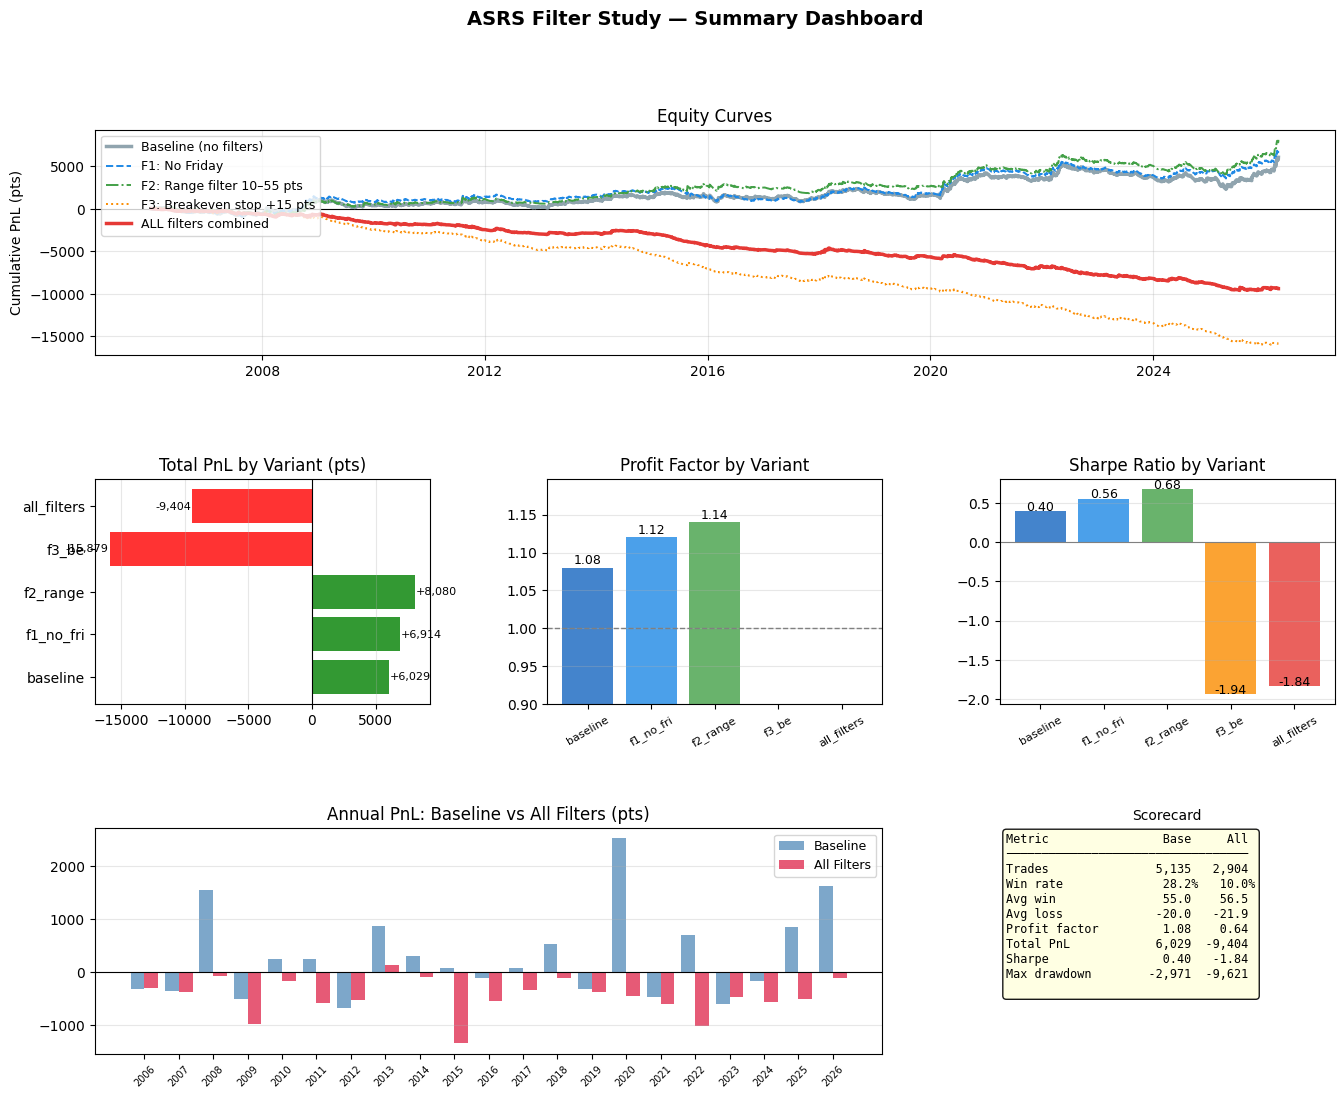

Saved: asrs_filters_dashboard.png


In [16]:
fig = plt.figure(figsize=(16, 12))
fig.suptitle('ASRS Filter Study — Summary Dashboard', fontsize=14, fontweight='bold')
gs = gridspec.GridSpec(3, 3, figure=fig, hspace=0.55, wspace=0.35)

# 1. Equity curves (top span)
ax1 = fig.add_subplot(gs[0, :])
for key, (color, ls, label) in colors.items():
    df_v = results[key]
    cum  = df_v['pnl'].cumsum()
    lw   = 2.5 if key in ('all_filters', 'baseline') else 1.4
    ax1.plot(cum.index, cum.values, color=color, lw=lw, ls=ls, label=label,
             zorder=5 if key == 'all_filters' else 3)
ax1.axhline(0, color='black', lw=0.8)
ax1.set_ylabel('Cumulative PnL (pts)')
ax1.set_title('Equity Curves')
ax1.legend(fontsize=9, loc='upper left')
ax1.grid(True, alpha=0.3)

# 2. Total PnL bar chart
ax2 = fig.add_subplot(gs[1, 0])
labels_order = list(colors.keys())
pnl_vals = [results[k]['pnl'].sum() for k in labels_order]
bar_colors2 = ['green' if v > 0 else 'red' for v in pnl_vals]
ax2.barh(labels_order, pnl_vals, color=bar_colors2, alpha=0.8)
ax2.axvline(0, color='black', lw=0.8)
for i, v in enumerate(pnl_vals):
    ax2.text(v + (100 if v >= 0 else -100), i, f'{v:+,.0f}',
             va='center', ha='left' if v >= 0 else 'right', fontsize=8)
ax2.set_title('Total PnL by Variant (pts)')
ax2.grid(True, axis='x', alpha=0.3)

# 3. Profit factor comparison
ax3 = fig.add_subplot(gs[1, 1])
pf_vals = [compute_metrics(results[k])['profit_factor'] for k in labels_order]
ax3.bar(labels_order, pf_vals, color=['#1565C0', '#1E88E5', '#43A047', '#FB8C00', '#E53935'], alpha=0.8)
ax3.axhline(1.0, color='gray', ls='--', lw=1)
ax3.set_ylim(0.9, None)
ax3.set_title('Profit Factor by Variant')
ax3.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(pf_vals):
    ax3.text(i, v + 0.005, f'{v:.2f}', ha='center', fontsize=9)
ax3.grid(True, axis='y', alpha=0.3)

# 4. Sharpe comparison
ax4 = fig.add_subplot(gs[1, 2])
sharpe_vals = [compute_metrics(results[k])['sharpe'] for k in labels_order]
ax4.bar(labels_order, sharpe_vals, color=['#1565C0', '#1E88E5', '#43A047', '#FB8C00', '#E53935'], alpha=0.8)
ax4.axhline(0, color='gray', lw=0.8)
ax4.set_title('Sharpe Ratio by Variant')
ax4.tick_params(axis='x', rotation=30, labelsize=8)
for i, v in enumerate(sharpe_vals):
    ax4.text(i, v + 0.01, f'{v:.2f}', ha='center', fontsize=9)
ax4.grid(True, axis='y', alpha=0.3)

# 5. Annual PnL side-by-side (baseline vs all_filters)
ax5 = fig.add_subplot(gs[2, :2])
years_str = ann_compare.index.astype(str)
x5 = np.arange(len(years_str))
w5 = 0.4
ax5.bar(x5 - w5/2, ann_compare['baseline'],    w5, color='steelblue', alpha=0.7, label='Baseline')
ax5.bar(x5 + w5/2, ann_compare['all_filters'], w5, color='crimson',   alpha=0.7, label='All Filters')
ax5.axhline(0, color='black', lw=0.8)
ax5.set_xticks(x5)
ax5.set_xticklabels(years_str, rotation=45, fontsize=7)
ax5.set_title('Annual PnL: Baseline vs All Filters (pts)')
ax5.legend(fontsize=9)
ax5.grid(True, axis='y', alpha=0.3)

# 6. Key stats text box
ax6 = fig.add_subplot(gs[2, 2])
ax6.axis('off')
m_a = compute_metrics(results['all_filters'])
m_b = compute_metrics(results['baseline'])
stats_text = (
    f"{'Metric':<18} {'Base':>7} {'All':>7}\n"
    f"{'─'*34}\n"
    f"{'Trades':<18} {m_b['n_trades']:>7,} {m_a['n_trades']:>7,}\n"
    f"{'Win rate':<18} {m_b['win_rate_%']:>7.1f}% {m_a['win_rate_%']:>6.1f}%\n"
    f"{'Avg win':<18} {m_b['avg_win_pts']:>7.1f} {m_a['avg_win_pts']:>7.1f}\n"
    f"{'Avg loss':<18} {m_b['avg_loss_pts']:>7.1f} {m_a['avg_loss_pts']:>7.1f}\n"
    f"{'Profit factor':<18} {m_b['profit_factor']:>7.2f} {m_a['profit_factor']:>7.2f}\n"
    f"{'Total PnL':<18} {m_b['total_pnl_pts']:>7,.0f} {m_a['total_pnl_pts']:>7,.0f}\n"
    f"{'Sharpe':<18} {m_b['sharpe']:>7.2f} {m_a['sharpe']:>7.2f}\n"
    f"{'Max drawdown':<18} {m_b['max_dd_pts']:>7,.0f} {m_a['max_dd_pts']:>7,.0f}\n"
)
ax6.text(0.02, 0.98, stats_text, transform=ax6.transAxes,
         fontsize=8.5, verticalalignment='top', fontfamily='monospace',
         bbox=dict(boxstyle='round', facecolor='lightyellow', alpha=0.9))
ax6.set_title('Scorecard', fontsize=10)

plt.savefig(ROOT / 'data' / 'asrs_filters_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_filters_dashboard.png')

## 11. F1 + F2 Combined (No Breakeven) — Best Variant

F3 (breakeven stop) destroys the strategy by converting EOD runners into 0-pt trades.  
This section isolates **F1 + F2 only** — no Friday + signal bar range 10–55 pts.

In [17]:
# Run F1+F2 (no breakeven) — the real best variant
results['f1_f2'] = run_backtest_filtered(no_friday=True, range_filter=True, use_breakeven=False)
print(f'f1_f2 : {len(results["f1_f2"]):,} trades')

# Show updated summary with all 6 variants
rows_all = [compute_metrics(results[k], label=k)
            for k in ['baseline', 'f1_no_fri', 'f2_range', 'f3_be', 'all_filters', 'f1_f2']]
summary_all = pd.DataFrame(rows_all).set_index('label')

print('\n=== Full Variant Comparison (including F1+F2) ===')
print(summary_all[cols_display].to_string())

f1_f2 : 2,904 trades

=== Full Variant Comparison (including F1+F2) ===
             n_trades  win_rate_%  avg_win_pts  avg_loss_pts  win_loss_ratio  profit_factor  total_pnl_pts  avg_trade_pts  sharpe  max_dd_pts
label                                                                                                                                        
baseline         5135        28.2         55.0         -20.0            2.75           1.08         6029.0           1.17    0.40     -2971.0
f1_no_fri        4121        28.2         56.3         -19.7            2.85           1.12         6914.0           1.68    0.56     -2045.0
f2_range         3654        29.6         61.3         -22.6            2.71           1.14         8080.0           2.21    0.68     -2314.0
f3_be            5135        11.3         46.3         -18.3            2.52           0.63       -15879.0          -3.09   -1.94    -16085.0
all_filters      2904        10.0         56.5         -21.9            2.58

In [18]:
# Full scorecard: F1+F2 vs baseline
m_f1f2 = compute_metrics(results['f1_f2'], label='f1_f2')
m_b    = compute_metrics(results['baseline'], label='baseline')

print('=== F1+F2 vs Baseline — Full Scorecard ===')
print(f'{"Metric":<22}  {"Baseline":>12}  {"F1+F2":>12}  {"Change":>10}')
print('-' * 62)
metrics_show = [
    ('n_trades',       'Trades',        ''),
    ('win_rate_%',     'Win rate',      '%'),
    ('avg_win_pts',    'Avg win',       ' pts'),
    ('avg_loss_pts',   'Avg loss',      ' pts'),
    ('win_loss_ratio', 'Win/Loss ratio','x'),
    ('profit_factor',  'Profit factor', ''),
    ('total_pnl_pts',  'Total PnL',    ' pts'),
    ('avg_trade_pts',  'Avg trade',    ' pts'),
    ('sharpe',         'Sharpe',        ''),
    ('max_dd_pts',     'Max drawdown', ' pts'),
    ('n_stop',         'Stop-outs',     ''),
    ('n_eod',          'EOD exits',     ''),
]
for key, label, unit in metrics_show:
    b = m_b.get(key, 0)
    a = m_f1f2.get(key, 0)
    if isinstance(b, float) or isinstance(a, float):
        chg  = f'{a-b:+.2f}'
        b_s, a_s = f'{b:.2f}', f'{a:.2f}'
    else:
        chg  = f'{a-b:+,}'
        b_s, a_s = f'{b:,}', f'{a:,}'
    print(f'{label:<22}  {b_s+unit:>12}  {a_s+unit:>12}  {chg:>10}')

=== F1+F2 vs Baseline — Full Scorecard ===
Metric                      Baseline         F1+F2      Change
--------------------------------------------------------------
Trades                         5,135         2,904      -2,231
Win rate                      28.20%        29.50%       +1.30
Avg win                    55.00 pts     63.20 pts       +8.20
Avg loss                  -20.00 pts    -22.60 pts       -2.60
Win/Loss ratio                 2.75x         2.80x       +0.05
Profit factor                   1.08          1.17       +0.09
Total PnL                6029.00 pts   8008.00 pts    +1979.00
Avg trade                   1.17 pts      2.76 pts       +1.59
Sharpe                          0.40          0.83       +0.43
Max drawdown            -2971.00 pts  -1863.00 pts    +1108.00
Stop-outs                      3,505         1,947      -1,558
EOD exits                      1,630           957        -673


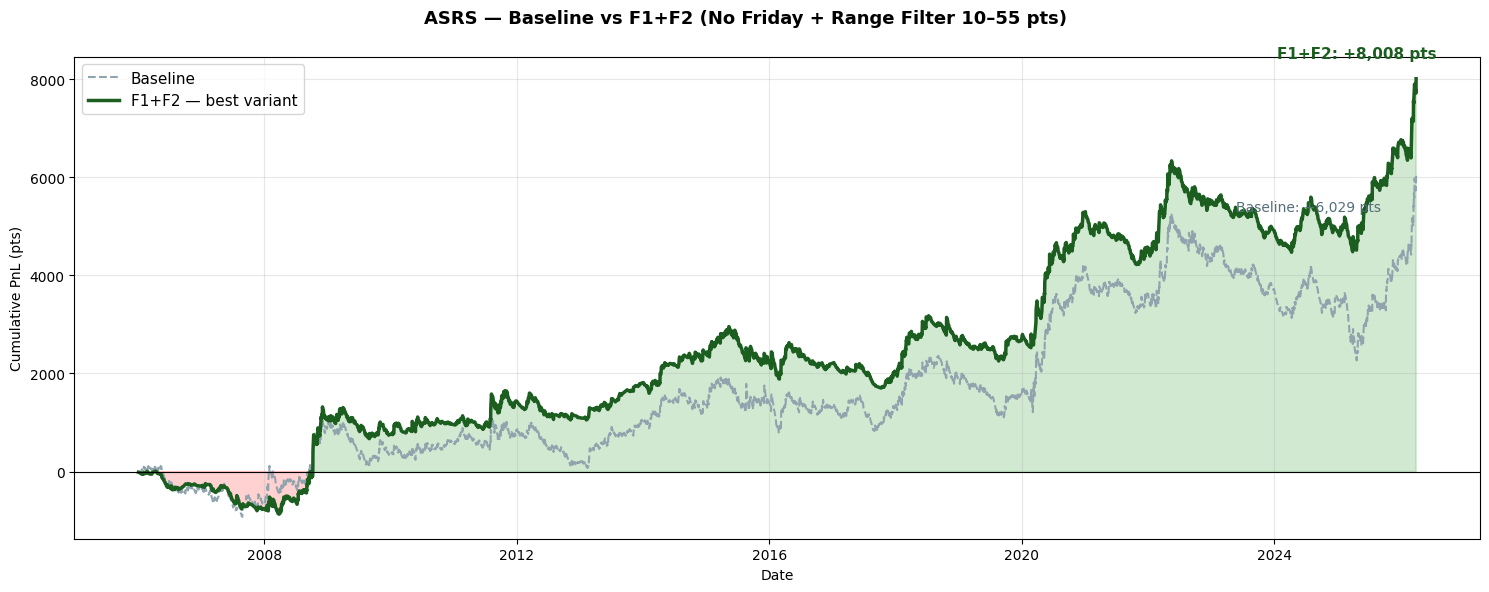

Saved: asrs_f1f2_equity.png


In [19]:
# Equity curve: baseline vs F1+F2
fig, ax = plt.subplots(figsize=(15, 6))
fig.suptitle('ASRS — Baseline vs F1+F2 (No Friday + Range Filter 10–55 pts)', fontsize=13, fontweight='bold')

cum_base = results['baseline']['pnl'].cumsum()
cum_f1f2 = results['f1_f2']['pnl'].cumsum()

ax.fill_between(cum_f1f2.index, cum_f1f2.values, 0,
                where=cum_f1f2.values >= 0, alpha=0.18, color='green')
ax.fill_between(cum_f1f2.index, cum_f1f2.values, 0,
                where=cum_f1f2.values  < 0, alpha=0.18, color='red')

ax.plot(cum_base.index, cum_base.values, color='#90A4AE', lw=1.5, ls='--', label='Baseline')
ax.plot(cum_f1f2.index, cum_f1f2.values, color='#1B5E20', lw=2.5,          label='F1+F2 — best variant')
ax.axhline(0, color='black', lw=0.8)

ax.annotate(f'Baseline: {cum_base.iloc[-1]:+,.0f} pts',
            xy=(cum_base.index[-1], cum_base.iloc[-1]),
            xytext=(-130, -25), textcoords='offset points',
            color='#546E7A', fontsize=10)
ax.annotate(f'F1+F2: {cum_f1f2.iloc[-1]:+,.0f} pts',
            xy=(cum_f1f2.index[-1], cum_f1f2.iloc[-1]),
            xytext=(-100, 15), textcoords='offset points',
            color='#1B5E20', fontsize=11, fontweight='bold')

ax.set_ylabel('Cumulative PnL (pts)')
ax.set_xlabel('Date')
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(ROOT / 'data' / 'asrs_f1f2_equity.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: asrs_f1f2_equity.png')

In [20]:
# Annual table: baseline vs F1+F2
df_f1f2  = results['f1_f2']
ann_f1f2 = df_f1f2.groupby(df_f1f2.index.year)['pnl'].sum().round(1)
ann_f1f2_compare = pd.DataFrame({'baseline': ann_base, 'f1_f2': ann_f1f2})
ann_f1f2_compare['improvement'] = (ann_f1f2_compare['f1_f2'] - ann_f1f2_compare['baseline']).round(1)

print('=== Annual PnL: Baseline vs F1+F2 ===')
print(f'{"Year":<6}  {"Baseline":>10}  {"F1+F2":>10}  {"Improvement":>12}')
print('-' * 43)
for yr, row in ann_f1f2_compare.iterrows():
    marker = ' ✓' if row['improvement'] > 0 else ' ✗'
    print(f'{yr:<6}  {row["baseline"]:>+10.0f}  {row["f1_f2"]:>+10.0f}  {row["improvement"]:>+12.0f}{marker}')

better = (ann_f1f2_compare['improvement'] > 0).sum()
print(f'\nF1+F2 beats baseline in {better}/{len(ann_f1f2_compare)} years')

=== Annual PnL: Baseline vs F1+F2 ===
Year      Baseline       F1+F2   Improvement
-------------------------------------------
2006          -311        -285           +27 ✓
2007          -355        -488          -133 ✗
2008         +1537       +1828          +290 ✓
2009          -518        -313          +205 ✓
2010          +250        +225           -25 ✗
2011          +243        +474          +232 ✓
2012          -672        -340          +333 ✓
2013          +860        +692          -168 ✗
2014          +303        +644          +341 ✓
2015           +74        -194          -268 ✗
2016          -106         -54           +52 ✓
2017           +80        -141          -221 ✗
2018          +523        +639          +116 ✓
2019          -322         -19          +303 ✓
2020         +2515       +2554           +38 ✓
2021          -478        -645          -167 ✗
2022          +705        +949          +244 ✓
2023          -603        -598            +5 ✓
2024          -165         

## 12. Export

In [21]:
# Export all trades
frames = []
for key, df in results.items():
    tmp = df.copy()
    tmp['variant'] = key
    frames.append(tmp.reset_index())

all_trades = pd.concat(frames, ignore_index=True)
trades_path = ROOT / 'data' / 'asrs_filters_trades.csv'
all_trades.to_csv(trades_path, index=False)
print(f'Exported {len(all_trades):,} rows → {trades_path}')

# Export summary
summary_path = ROOT / 'data' / 'asrs_filters_summary.csv'
summary.to_csv(summary_path)
print(f'Exported summary → {summary_path}')

print('\n=== FINAL SUMMARY ===')
print(summary[cols_display].to_string())

Exported 23,853 rows → c:\Users\ali\Desktop\Projet-INFO-2AS2\data\asrs_filters_trades.csv
Exported summary → c:\Users\ali\Desktop\Projet-INFO-2AS2\data\asrs_filters_summary.csv

=== FINAL SUMMARY ===
             n_trades  win_rate_%  avg_win_pts  avg_loss_pts  win_loss_ratio  profit_factor  total_pnl_pts  avg_trade_pts  sharpe  max_dd_pts
label                                                                                                                                        
baseline         5135        28.2         55.0         -20.0            2.75           1.08         6029.0           1.17    0.40     -2971.0
f1_no_fri        4121        28.2         56.3         -19.7            2.85           1.12         6914.0           1.68    0.56     -2045.0
f2_range         3654        29.6         61.3         -22.6            2.71           1.14         8080.0           2.21    0.68     -2314.0
f3_be            5135        11.3         46.3         -18.3            2.52           0.6